# **Customer Churn Prediction Platform for Retail Business Using Machine Learning and MLOps - Model Explainability**

---

## **Import Library**

---

In [1]:
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

---

## **Load Data**

---

In [ ]:
# Define paths and constants
MODEL_PATH = "../models/best_model.pkl"
TEST_DATA_PATH = "../data/processed/test.csv"
SHAP_OUTPUT_DIR = Path("../reports/shap")
SHAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define the target column
TARGET_COLUMN = "churn_flag"

In [3]:
# Load the model
model = joblib.load(MODEL_PATH)

# Load the test data
test_df = pd.read_csv(TEST_DATA_PATH)

# Prepare test data
X_test = test_df.drop(columns=[TARGET_COLUMN])
y_test = test_df[TARGET_COLUMN]

# Check shapes
X_test.shape, y_test.shape

((20000, 83), (20000,))

**Insight:**

Data loaded succesfully

---

## **SHAP Checking**

---

### **Take a Sample**

---

In [4]:
# Sample a subset of the test data for SHAP analysis (to speed up computation)
X_sample = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

# Check shape of the sampled data
X_sample.shape

(1000, 83)

**Insight:**

The sample taken consists of 1000 rows and 83 columns.


---

### **SHAP Explainer**


---

In [5]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

shap_values = explainer(X_sample)

**Insight:**

Shap Explainer created succesfully

---

### **Global Feature Importance**

---

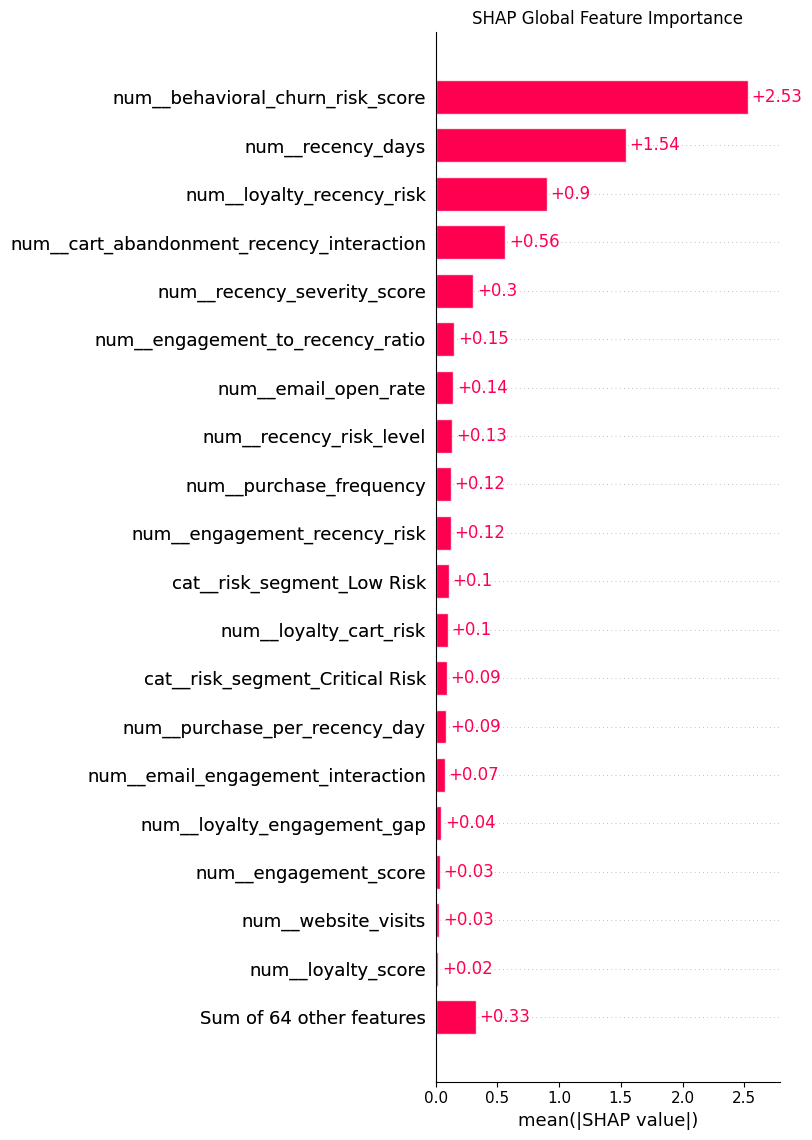

In [6]:
# Plot SHAP global feature importance
shap.plots.bar(shap_values, max_display=20, show=False)

plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.savefig(SHAP_OUTPUT_DIR / "shap_global_feature_importance.png", dpi=300)
plt.show()

**Insight:**

The chart above shows the **global feature importance** based on the mean absolute SHAP value, represented as `mean(|SHAP value|)`. This value indicates the average magnitude of each feature’s contribution to the model prediction. The higher the value, the greater the influence of that feature on the model output.

Based on the SHAP results, the most influential feature is `num__behavioral_churn_risk_score`, with an importance value of **2.53**. This indicates that the model relies heavily on the customer behavioral churn risk score when generating churn predictions. This feature acts as the main signal for distinguishing customers with higher and lower churn risk.

The second most important feature is `num__recency_days`, with a value of **1.54**. This shows that the time elapsed since the customer’s last activity plays a major role in predicting churn. In churn analysis, customers who have been inactive for a longer period are generally more likely to be classified as having a higher churn risk.

The next important feature is `num__loyalty_recency_risk`, with a value of **0.90**. This suggests that the interaction between customer loyalty and recent activity is an important signal for the model. In other words, the model does not only consider whether a customer is loyal, but also whether that customer has remained active recently.

Another relevant feature is `num__cart_abandonment_recency_interaction`, with an importance value of **0.56**. This feature indicates that the interaction between cart abandonment behavior and recency provides additional predictive information. Customers who abandon their carts, especially in relation to their recent activity patterns, may require closer attention in retention strategies.

Other recency-related features, such as `num__recency_severity_score`, `num__engagement_to_recency_ratio`, and `num__recency_risk_level`, also appear among the important features. This reinforces the finding that the model is highly sensitive to customers’ recent behavioral patterns.

Overall, the SHAP results show that the churn prediction model is mainly influenced by three groups of signals:

1. **Customer behavioral risk**, especially through `behavioral_churn_risk_score`.
2. **Recency of customer activity**, such as `recency_days` and `recency_severity_score`.
3. **Interactions between recency, loyalty, engagement, and cart abandonment behavior**.

Features such as `num__engagement_score`, `num__website_visits`, and `num__loyalty_score` have relatively low importance values. This means that these features are still used by the model, but their contribution to the prediction is much smaller than the main risk- and recency-based features.

It is important to note that this chart only explains the **magnitude of feature influence**, not the direction of the effect. In other words, global SHAP importance does not show whether a feature increases or decreases the predicted probability of churn. To understand the direction of each feature’s impact, further analysis using a SHAP summary plot, beeswarm plot, or dependence plot is required.

From a business perspective, the main insight is that customer retention strategies should prioritize customers with high behavioral churn risk scores, poor recency indicators, and declining engagement or loyalty patterns. Customers who were previously loyal but have recently become inactive should also be considered high-priority targets for churn prevention initiatives.

---

### **SHAP Summary Plot**

---

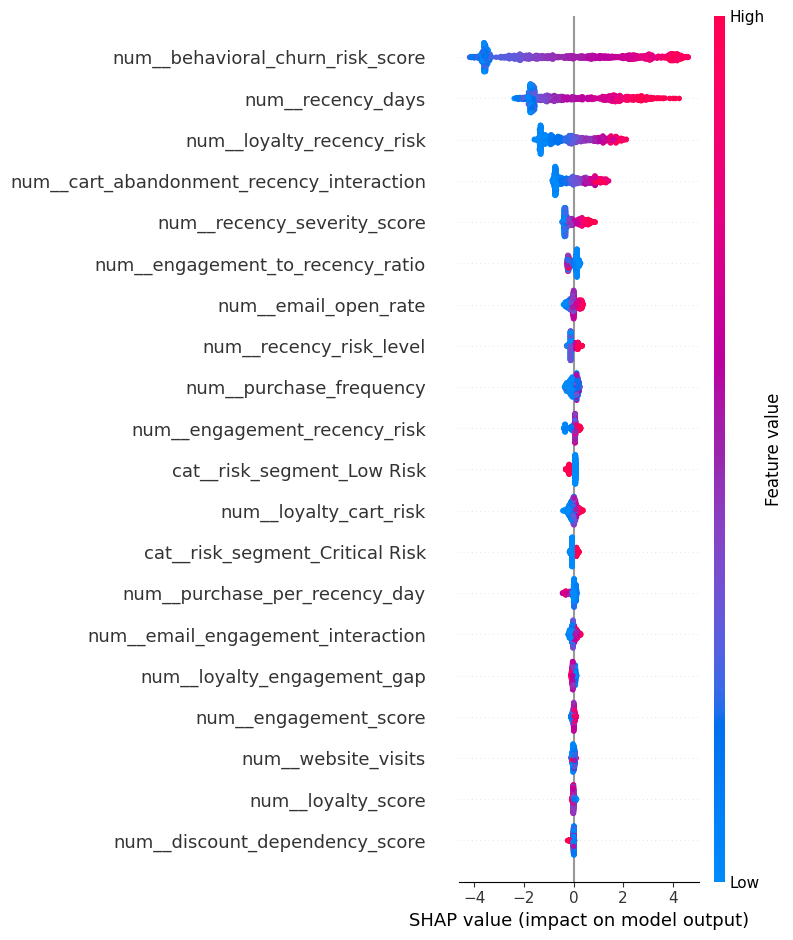

In [7]:
# Plot SHAP summary plot
shap.summary_plot(
    shap_values.values,
    X_sample,
    max_display=20,
    show=False
)

plt.tight_layout()
plt.savefig(SHAP_OUTPUT_DIR / "shap_summary_plot.png", dpi=300)
plt.show()

In [8]:
# Create a DataFrame for feature importance based on mean absolute SHAP values
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    "feature": X_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

# Display the top 20 features
feature_importance.head(20)

,feature,mean_abs_shap
55,num__behavioral_churn_risk_score,2.530778
3,num__recency_days,1.542451
47,num__loyalty_recency_risk,0.902243
37,num__cart_abandonment_recency_interaction,0.564801
21,num__recency_severity_score,0.303210
12,num__engagement_to_recency_ratio,0.149558
6,num__email_open_rate,0.141150
16,num__recency_risk_level,0.134642
0,num__purchase_frequency,0.123484
43,num__engagement_recency_risk,0.119976


In [9]:
# Save feature importance to CSV
feature_importance.to_csv(
    SHAP_OUTPUT_DIR / "shap_feature_importance.csv",
    index=False
)

**Insight:**

The SHAP summary plot explains both the **importance** and the **direction of impact** of each feature on the model prediction. Each point represents one customer observation, while the position on the X-axis shows the SHAP value, which indicates how much that feature contributes to the model output.

A positive SHAP value means the feature pushes the prediction toward the target class, which in this case is assumed to be **churn**. A negative SHAP value means the feature reduces the predicted probability of churn. The color represents the feature value, where pink indicates a high feature value and blue indicates a low feature value.

Based on the plot, the most influential feature is `num__behavioral_churn_risk_score`. High values of this feature are mostly located on the positive SHAP side, meaning that customers with a high behavioral churn risk score are more likely to be predicted as churn. In contrast, low values of this feature tend to have negative SHAP values, reducing the predicted churn risk. This confirms that the behavioral churn risk score is the strongest signal used by the model.

The second most important feature is `num__recency_days`. High values of `recency_days` are associated with positive SHAP values, indicating that customers who have not been active for a longer period are more likely to be classified as churn. This is consistent with churn behavior, where longer inactivity usually indicates a higher probability of customer disengagement.

The feature `num__loyalty_recency_risk` also has a strong positive impact when its value is high. This suggests that the model identifies customers with risky combinations of loyalty and recent activity patterns as more likely to churn. In practical terms, customers who were previously loyal but have recently become less active may represent an important retention target.

Another important feature is `num__cart_abandonment_recency_interaction`. High values of this feature tend to push the prediction toward churn. This indicates that cart abandonment behavior, especially when combined with recency-related patterns, provides meaningful information for identifying customers at risk.

The feature `num__recency_severity_score` also shows a clear pattern where higher values increase the predicted churn risk. This reinforces the idea that the model is highly sensitive to the severity of customer inactivity.

Several other features, such as `num__engagement_to_recency_ratio`, `num__email_open_rate`, `num__recency_risk_level`, `num__purchase_frequency`, and `num__engagement_recency_risk`, have smaller impacts compared to the top features. Most of their SHAP values are concentrated around zero, meaning their contribution to the prediction is relatively limited. However, they may still provide additional supporting signals for the model.

For categorical features, such as `cat__risk_segment_Low Risk` and `cat__risk_segment_Critical Risk`, the interpretation depends on whether the category is active. The `Low Risk` segment tends to reduce churn prediction, while the `Critical Risk` segment tends to increase churn prediction. This indicates that the model uses risk segmentation consistently with expected business logic.

Overall, the SHAP summary plot shows that the churn prediction model is mainly driven by customer risk and recency-related features. Customers with high behavioral churn risk scores, long inactivity periods, high loyalty-recency risk, and strong cart abandonment-recency patterns are more likely to be predicted as churn.

From a business perspective, these findings suggest that retention strategies should prioritize customers who show signs of recent inactivity, increasing behavioral risk, declining loyalty, or abandoned purchase intent. These customers should be targeted with reactivation campaigns, personalized offers, loyalty incentives, or reminder-based engagement strategies.

---

### **Dependence Plot**

---

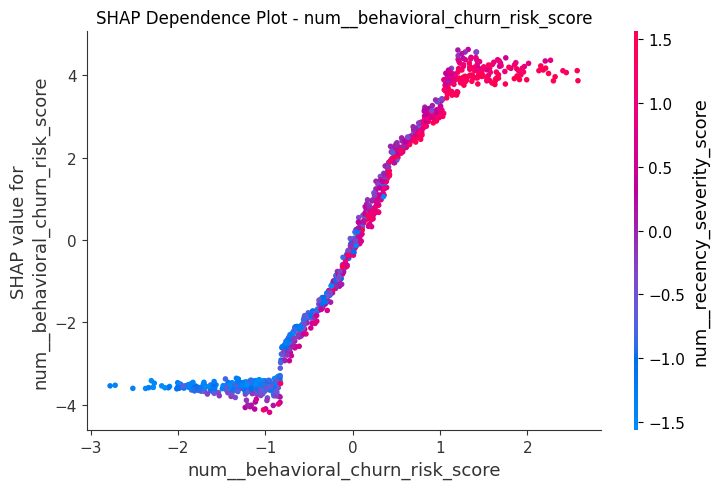

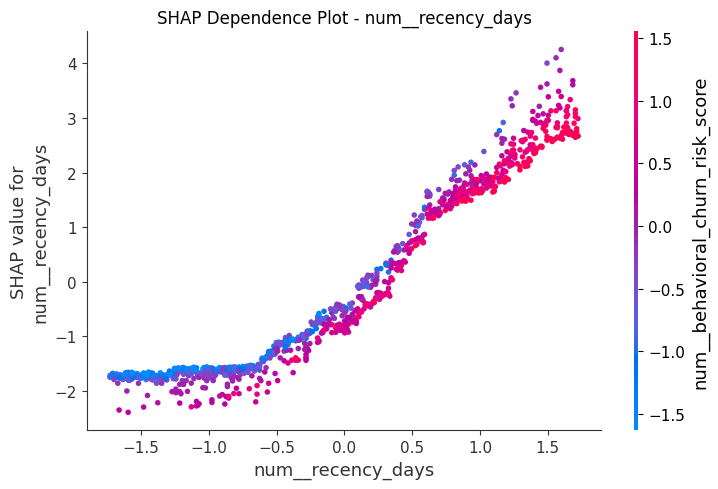

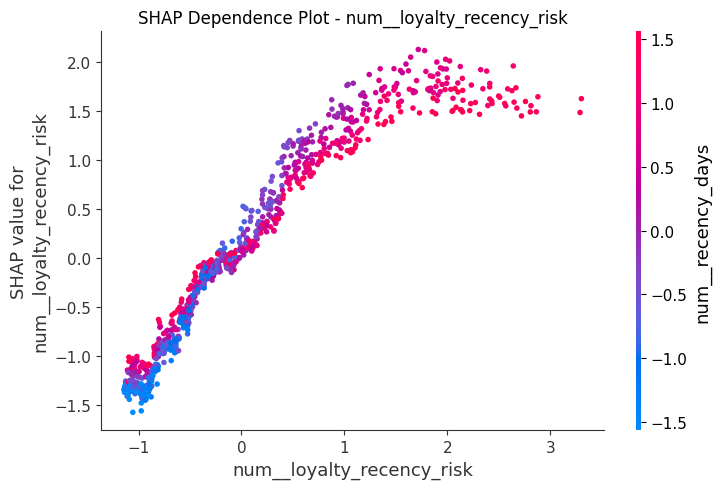

In [ ]:
# Generate SHAP dependence plots for the top 3 features
top_features = feature_importance.head(3)["feature"].tolist()

# Generate SHAP dependence plots for the top features
for feature in top_features:
    safe_feature_name = (
        feature
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "_")
    )

    shap.dependence_plot(
        feature,
        shap_values.values,
        X_sample,
        show=False
    )

    plt.title(f"SHAP Dependence Plot - {feature}")
    plt.tight_layout()
    plt.savefig(
        SHAP_OUTPUT_DIR / f"shap_dependence_{safe_feature_name}.png",
        dpi=300
    )
    plt.show()

**Insight:**

The SHAP dependence plots show how individual feature values affect the model prediction. Each point represents one customer observation.

In these plots:

- The X-axis represents the actual feature value.
- The Y-axis represents the SHAP value for that feature.
- A positive SHAP value means the feature pushes the prediction toward churn.
- A negative SHAP value means the feature reduces the predicted probability of churn.
- The color represents the value of another interacting feature, where blue indicates low values and pink indicates high values.

Since the feature values range from negative to positive values, the variables are likely standardized or scaled. Therefore, a value around 0 can be interpreted as approximately the average level of the feature.

---

**Dependence Plot: `num__behavioral_churn_risk_score`**

The first plot shows the relationship between `num__behavioral_churn_risk_score` and its SHAP contribution to the churn prediction.

The pattern is strongly increasing. When the behavioral churn risk score is low, the SHAP value is highly negative, meaning that customers with low behavioral risk strongly reduce the model’s predicted churn probability.

As the feature value increases, the SHAP value rises sharply. Around the middle range, the contribution moves from negative to positive. This indicates a transition point where the customer starts to be considered more likely to churn by the model.

At higher values of `num__behavioral_churn_risk_score`, the SHAP values become strongly positive. This means that customers with high behavioral churn risk scores strongly increase the predicted probability of churn.

The color interaction with `num__recency_severity_score` shows that customers with both high behavioral churn risk and high recency severity tend to have stronger positive SHAP values. This indicates that recent inactivity severity amplifies the effect of behavioral churn risk.
  
`num__behavioral_churn_risk_score` has a very strong and direct impact on churn prediction. Higher behavioral risk scores substantially increase the predicted probability of churn.

---

**Dependence Plot: `num__recency_days`**

The second plot shows the relationship between `num__recency_days` and the model’s churn prediction.

The plot shows a clear upward trend. Low values of `num__recency_days` are associated with negative SHAP values, meaning that customers who were recently active tend to have lower predicted churn risk.

As `num__recency_days` increases, the SHAP value also increases. Around the middle range, the effect shifts from negative to positive, suggesting that customers start to become more at risk once their inactivity period increases beyond a certain level.

At higher values of `num__recency_days`, the SHAP values become clearly positive. This indicates that longer inactivity strongly increases the predicted probability of churn.

The color interaction with `num__behavioral_churn_risk_score` shows that customers with high recency days and high behavioral churn risk scores tend to be concentrated in the upper-right area of the plot. This means that the combination of long inactivity and high behavioral risk produces a stronger churn signal.

`num__recency_days` is an important churn indicator. The longer a customer has been inactive, the more the model increases the predicted probability of churn.

---

**Dependence Plot: `num__loyalty_recency_risk`**

The third plot shows the relationship between `num__loyalty_recency_risk` and churn prediction.

The pattern is also increasing, although it begins to flatten at higher values. When `num__loyalty_recency_risk` is low, the SHAP value is negative, indicating that customers with low loyalty-recency risk are less likely to be predicted as churn.

As the feature value increases, the SHAP value moves upward. Around the average range, the contribution becomes close to neutral, and then turns positive as the loyalty-recency risk increases.

At high values, the SHAP value reaches a positive level and then starts to stabilize. This suggests a saturation effect: after a certain point, the feature continues to indicate churn risk, but the additional increase in impact becomes smaller.

The color interaction with `num__recency_days` shows that customers with higher recency days tend to have stronger positive SHAP values. This means that loyalty-recency risk becomes more important when the customer has also been inactive for a longer period.

`num__loyalty_recency_risk` captures the risk associated with customers whose loyalty profile is combined with declining recent activity. Previously loyal customers who become inactive may represent an important churn-risk segment.

---

**Overall Interpretation**

Across all three dependence plots, the model shows a consistent pattern: higher values of risk-related and recency-related features increase the predicted probability of churn.

The model is mainly driven by:

1. `num__behavioral_churn_risk_score` as the strongest behavioral risk signal.
2. `num__recency_days` as an indicator of customer inactivity.
3. `num__loyalty_recency_risk` as a combined signal of loyalty and declining recent activity.

From a business perspective, customers with high behavioral churn risk, long inactivity periods, high loyalty-recency risk, and high recency severity should be prioritized for retention actions. These customers are suitable targets for reactivation campaigns, personalized offers, loyalty incentives, or reminder-based engagement campaigns.

---

### **Local explanation per customer**

---

In [18]:
# Generate predictions and probabilities for the test set
y_proba = model.predict_proba(X_test)[:, 1]

prediction_df = X_test.copy()
prediction_df["actual_churn"] = y_test.values
prediction_df["churn_probability"] = y_proba

high_risk_customers = prediction_df.sort_values(
    "churn_probability",
    ascending=False
)

high_risk_customers.head()

,num__purchase_frequency,num__avg_order_value,num__total_spent,num__recency_days,num__website_visits,num__discount_usage_rate,num__email_open_rate,num__cart_abandonment_rate,num__loyalty_score,num__engagement_score,...,cat__customer_segment_VIP,cat__preferred_channel_In-Store,cat__preferred_channel_Mobile App,cat__preferred_channel_Online,cat__risk_segment_Critical Risk,cat__risk_segment_High Risk,cat__risk_segment_Low Risk,cat__risk_segment_Medium Risk,actual_churn,churn_probability
17614,0.572817,-1.264956,-0.315476,1.665531,1.113668,1.445306,1.001556,1.511852,-1.598003,-0.306007,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.999960
7312,0.572817,1.352161,1.075763,1.665531,0.871960,0.570260,0.797788,1.295001,-1.367011,-0.306007,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0.999957
6784,-0.264385,1.173560,0.164887,1.646526,-0.514677,0.339984,0.757035,1.511852,-1.482507,-0.484554,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1,0.999957
11787,0.014682,1.047108,0.527060,1.475482,0.388546,-0.489007,0.838542,1.598592,-1.444008,-0.484554,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1,0.999957
8602,-0.613219,-1.055995,-0.603113,1.703541,-0.476512,0.938701,0.960802,1.511852,-1.675000,-0.335765,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1,0.999952


In [19]:
# Select a specific customer for local explanation 
customer_index = high_risk_customers.index[0]

customer_data = X_test.loc[[customer_index]]
customer_data

,num__purchase_frequency,num__avg_order_value,num__total_spent,num__recency_days,num__website_visits,num__discount_usage_rate,num__email_open_rate,num__cart_abandonment_rate,num__loyalty_score,num__engagement_score,...,cat__customer_segment_New,cat__customer_segment_Returning,cat__customer_segment_VIP,cat__preferred_channel_In-Store,cat__preferred_channel_Mobile App,cat__preferred_channel_Online,cat__risk_segment_Critical Risk,cat__risk_segment_High Risk,cat__risk_segment_Low Risk,cat__risk_segment_Medium Risk
17614,0.572817,-1.264956,-0.315476,1.665531,1.113668,1.445306,1.001556,1.511852,-1.598003,-0.306007,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [20]:
# Generate SHAP values for the selected customer
y_proba = model.predict_proba(X_test)[:, 1]

prediction_df = X_test.copy()
prediction_df["actual_churn"] = y_test.values
prediction_df["churn_probability"] = y_proba
prediction_df["predicted_churn"] = (prediction_df["churn_probability"] >= 0.5).astype(int)

high_risk_customers = prediction_df.sort_values(
    by="churn_probability",
    ascending=False
)

high_risk_customers[[
    "actual_churn",
    "predicted_churn",
    "churn_probability"
]].head(10)

,actual_churn,predicted_churn,churn_probability
17614,1,1,0.999960
7312,1,1,0.999957
6784,1,1,0.999957
11787,1,1,0.999957
8602,1,1,0.999952
128,1,1,0.999952
15095,1,1,0.999952
17685,1,1,0.999951
8298,1,1,0.999951
18801,1,1,0.999951


In [ ]:
# Select a specific customer for local explanation
customer_index = high_risk_customers.index[0]

# Extract the customer data for SHAP explanation
customer_data = X_test.loc[[customer_index]]

# Generate SHAP values for the selected customer
customer_summary = prediction_df.loc[
    [customer_index],
    ["actual_churn", "predicted_churn", "churn_probability"]
]

# Customer summary for the selected customer  
customer_summary

,actual_churn,predicted_churn,churn_probability
17614,1,1,0.99996


**Insight:**

**How to Read Scaled Customer Features**

The model uses preprocessed features. Numerical variables were standardized using `StandardScaler`, so the values shown here are not the original raw business values.

For numerical features:

- Positive value means the customer is above the average.
- Negative value means the customer is below the average.
- Value close to 0 means the customer is close to the average.
- Value greater than 1 usually means the customer is significantly above average.
- Value lower than -1 usually means the customer is significantly below average.

For categorical features:

- Value `1.0` means the customer belongs to that category.
- Value `0.0` means the customer does not belong to that category.

Therefore, the selected customer should be interpreted based on relative position compared to the training population, not as raw customer values.

---

**Local Business Explanation: Selected High-Risk Customer**

The selected customer has:

- Actual churn label: `1`
- Predicted churn label: `1`
- Churn probability: `0.999960`

This means the model correctly identified this customer as a churn case with extremely high confidence.

Because the input data has already been scaled, the numerical values should be interpreted relative to the average customer in the training data.

For this customer:

- `recency_days` is significantly above average, meaning the customer has been inactive for much longer than typical customers.
- `cart_abandonment_rate` is significantly above average, indicating strong purchase hesitation or checkout friction.
- `loyalty_score` is significantly below average, suggesting weak customer loyalty.
- `avg_order_value` is below average, meaning the customer has relatively low average spending per order.
- The customer belongs to the `Critical Risk` segment.
- The customer is categorized as a `New` customer.
- The preferred channel is `In-Store`.

From a business perspective, this customer represents a high-priority churn case. The model prediction is not only high in probability, but also supported by several behavioral signals: long inactivity, high cart abandonment, weak loyalty, and critical risk classification.

This customer should be prioritized for an immediate retention action, such as a personalized win-back offer, loyalty incentive, or direct reactivation campaign.

---

### **Waterfall Plot**

---

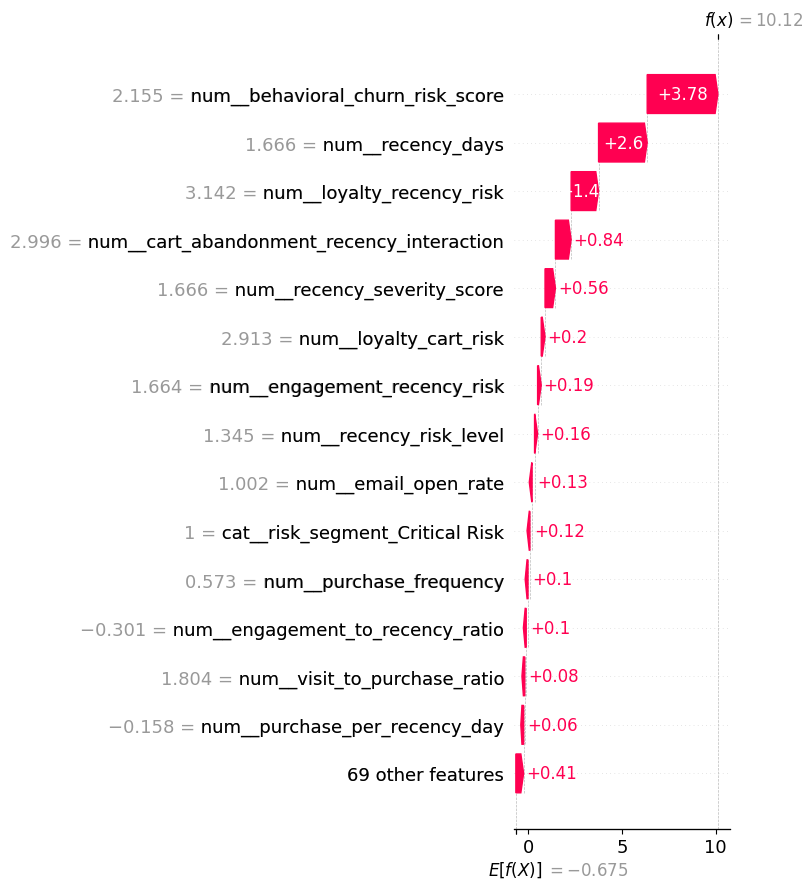

In [14]:
# Generate SHAP values for the selected customer
customer_shap_values = explainer(customer_data)

# Plot SHAP waterfall for the selected customer
shap.plots.waterfall(
    customer_shap_values[0],
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(SHAP_OUTPUT_DIR / "shap_waterfall_high_risk_customer.png", dpi=300)
plt.show()

**Insight:**

The SHAP waterfall plot explains the prediction for a single customer. It shows how each feature moves the model output from the baseline prediction to the final prediction.

The baseline value is `E[f(X)] = -0.675`, which represents the average model output before considering this customer's feature values. After adding all feature contributions, the final prediction becomes `f(x) = 10.12`. This indicates that the model assigns this customer a very high churn risk.

The largest positive contributor is `num__behavioral_churn_risk_score`, with a SHAP contribution of **+3.78**. This means that the customer's high behavioral churn risk score strongly increases the predicted probability of churn.

The second strongest contributor is `num__recency_days`, with a contribution of **+2.60**. This suggests that the customer has been inactive for a relatively long period, which significantly increases churn risk.

The feature `num__loyalty_recency_risk` also contributes positively, with a SHAP value of **+1.40**. This indicates that the combination of loyalty-related behavior and recent inactivity is an important churn signal for this customer.

Other features, such as `num__cart_abandonment_recency_interaction`, `num__recency_severity_score`, and `cat__risk_segment_Critical Risk`, also push the prediction toward churn, although with smaller contributions.

Overall, this customer is predicted to have a high churn risk because several key risk and recency-related features are strongly aligned in the same direction. From a business perspective, this customer should be prioritized for retention actions such as personalized offers, reactivation campaigns, loyalty incentives, or reminder-based engagement.

---